In [1]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import deeplake 
import torch



class patches_loader(Dataset):
    '''
    Class to handle patches stored as deeplake objects
    '''
    def __init__(self, train_or_test, WSI_id, scanner, to_torch=False):
        self.split = train_or_test
        self.WSI_id = WSI_id
        self.scanner = scanner
        directory = f"/home/leolr-int/nfs/data/data/patched/dim_256/{train_or_test}"
        #here we consider only Subset3
        file = f'Subset3_{train_or_test}_{WSI_id}_{scanner}'
        self.patches = deeplake.open_read_only(f'{directory}/{file}')
        self.to_torch = to_torch

    def summary(self):
        return self.patches.summary()
    
    # to specify a label and then access the columns of the deeplake dataset
    def __getitem__(self, idx):
        if self.to_torch:
            patch = self.patches[idx]
            img = torch.tensor(patch['patch'])
            label = torch.tensor(patch["label"], dtype=torch.long)
            area = torch.tensor(patch["area"], dtype=torch.long)
            x = torch.tensor(patch["x"], dtype=torch.long)
            y = torch.tensor(patch["y"], dtype=torch.long)
            w = torch.tensor(patch["w"], dtype=torch.long)
            h = torch.tensor(patch["h"], dtype=torch.long)
            
            metadata = {
                "area": area,
                "x": x,
                "y": y,
                "w": w,
                "h": h,
                }
            
            return {'img':img, 'label':label, 'metadata': metadata}
            
        else: 
            return self.patches[idx]
            # Example: patches[idx]['label']

    def __len__(self):
        return len(self.patches)
    
    def display(self, idx): 
        fig, axes = plt.subplots(figsize=(4, 4))
        axes.imshow(self.patches[idx]["patch"])
        plt.show()

    def to_embedding(self):
        return None 




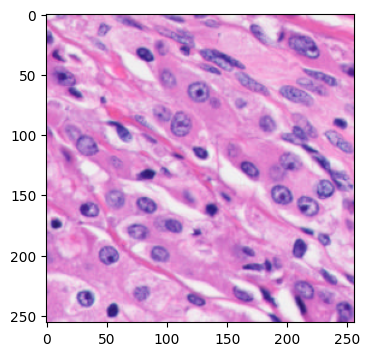

Dataset length: 10675
Columns:
  patch: kind=image, dtype=array(dtype=uint8, shape=(None, None, None))
  label: int32
  area : int32
  x    : int32
  y    : int32
  w    : int32
  h    : int32




In [2]:
#test

file_test = patches_loader('Train', 1, 'Akoya', to_torch=True)
file_test.display(200)
file_test[200]['label']
file_test.summary()



In [3]:
class multi_WSI_loader(Dataset):
    '''
    Class to handle several WSI from different scanners
    Used for training a neural network
    '''

    def __init__(self, WSI_ids, scanners, train_or_test='Train'):
        self.train_or_test = train_or_test
        self.WSI_ids = WSI_ids
        self.scanners = scanners
        
        # dictionary to store all the patches_loader objects
        self.datasets = []
        for scanner in scanners:
            for WSI_id in WSI_ids: 
                ds = patches_loader(train_or_test, WSI_id, scanner, to_torch=True)
                self.datasets.append(ds)

        # index mapping
        self.index_map = []
        for ds_idx, ds in enumerate(self.datasets):
            for i in range(len(ds)):
                self.index_map.append((ds_idx, i))
            
    # define indexing so that the dataloader can access data    
    def __getitem__(self, idx):
        ds_idx, sample_idx = self.index_map[idx]
        return self.datasets[ds_idx][sample_idx] #which is a patches_loader object
    
    def __len__(self):
        return len(self.index_map)

In [4]:
train_scanners = ['Akoya', 'Leica']
WSI_ids = [1,2,3]
target_scanner = ['Akoya'] if 'Akoya' in train_scanners else random.choice(train_scanners)
train_scanners.remove(target_scanner[0])
source_scanner = train_scanners

print(target_scanner)
print(source_scanner)

target_dataset = multi_WSI_loader(WSI_ids, target_scanner, train_or_test='Train')
source_dataset = multi_WSI_loader(WSI_ids, source_scanner, train_or_test='Train')


# DataLoaders
batch_size = 16
train_loader_source = DataLoader(source_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
train_loader_target = DataLoader(target_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)


for batch in train_loader_source:
    images = batch['img']
    labels = batch['label']
    metadata = batch['metadata']
    print("Source batch - Images shape:", images.shape, "Labels:", labels)
    break

for batch in train_loader_target:
    images = batch['img'].permute(0,3,2,1)
    labels = batch['label']
    metadata = batch['metadata']
    print("Target batch - Images shape:", images.shape, "Labels:", labels)
    break
    


['Akoya']
['Leica']
Source batch - Images shape: torch.Size([16, 256, 256, 3]) Labels: tensor([2, 0, 3, 3, 3, 2, 1, 2, 3, 2, 3, 2, 2, 3, 2, 2])
Target batch - Images shape: torch.Size([16, 3, 256, 256]) Labels: tensor([2, 2, 0, 3, 3, 2, 0, 3, 1, 3, 2, 3, 3, 3, 2, 2])


## Test with network handler


In [5]:
import torch
import torch.nn as nn
import random

class Neural_Network(nn.Module):
    """
    Initialises an Artificial Neural Network with the foundation encoder Gigapath 
    and 2 layers for classification (one to create embeddings, one to classify)

    """

    def __init__(self, BASE_MODEL_DIR, freeze_encoder: bool = True, OT: bool = False, num_classes: int = 5):
        super().__init__() #super constructor for ANN in PyTorch

        self.freeze_encoder = freeze_encoder
        self.OT = OT #maybe not useful here
        
        # Define encoder
        encoder_name = 'gigapath'
        encoder_dir = os.path.join(BASE_MODEL_DIR, "pre_trained_weights")
        encoder_path = os.path.join(encoder_dir, f"{encoder_name}.pth")
        encoder = torch.load(encoder_path, map_location=torch.device("cpu"), weights_only=False)
        self.encoder = encoder

        if self.freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False

        # Define bottle neck / embeddings
        # fixed parameter value for Gigapath
        in_dim = 1536
        self.bottle_neck = nn.Linear(in_dim, 1024)

        # Define classification head
        out_dim = num_classes
        self.head = nn.Linear(1024, out_dim)

        # Define sequential architecture
        def forward(self, x): 
            if self.freeze_encoder: 
                with torch.no_grad():
                    encoded = self.encoder(x)
                embedding = self.bottle_neck(encoded)
            else:
                embedding = self.bottle_neck(self.encoder(x))
            logits = self.head(embedding)
            return logits


In [6]:
import os
from typing import (
    Tuple, 
    Literal
)
import random
import torch
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.amp import GradScaler
from torch.utils.data import DataLoader
import deeplake
from sklearn.metrics import balanced_accuracy_score
from geomloss import SamplesLoss

# Ensuring reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False 

# Define global variables
metrics_train = {'running_loss':0, 'predictions':[], 'labels':[]}
metrics_val = {'running_loss':0, 'predictions':[], 'labels':[]}
WSI_ids_train = [1,2,3, 4, 5, 6, 7, 8, 9, 10] #to be completed
WSI_ids_val = [11,12,13,14,15]

# Defining OT-based loss function
loss_geom = SamplesLoss('sinkhorn', p=2, blur=0.1, scaling=0.95, verbose=False)
Lambda = 0.1 # strength of OT (0.1 is the value of the article)

class NetworkHandler:
    '''
    A class to handle training, inference and prediction
    '''

    def __init__(self, precision = 'mixed', freeze_encoder = True, embedding_mode = False, display = False):
        self.precision = precision
        self.freeze_encoder = freeze_encoder
        self.embedding_mode = embedding_mode
        self.display = display

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        BASE_MODEL_DIR = '/home/leolr-int/AGGCPerturbations/model_weights'
        self.model = Neural_Network(BASE_MODEL_DIR)
        self.model = self.model.to(self.device)

        self.use_amp = precision == 'mixed' and self.device == 'cuda'
        self.grad_scaler = GradScaler(enabled=self.use_amp)

    @torch.no_grad()
    def extract_embeddings(self, scanners, WSI_ids, train_or_test):
        # creates the deeplake database for embeddings
        # structure: one deeplake dataset per WSI, embeddings, scanner, WSI_id, Train or Test

        root_dir = '/home/leolr-int/nfs/transformed_data/my_embeddings'
        self.model.eval()
        for scanner in scanners:
            for id in WSI_ids:

                WSI = patches_loader(train_or_test, id, scanner, to_torch=True)
                iterator = range(1, len(WSI))
                for i in tqdm(iterator, desc=f'Extracting embeddings for {train_or_test}_{id}_{scanner}'):
                    patch = WSI[i]['img'].unsqueeze(0).permute(0,3,2,1) #insert dimension for batch and reorder axes
                    patch = patch.to(self.device)
                    print(patch.shape)

                    with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                        embedding = self.model.encoder(patch)
                    
                    embedding.detach().cpu()

                    path = f'Subset3_{train_or_test}_{id}_{scanner}'
                    final_destination = os.path.join(root_dir, path)
                    os.makedirs(final_destination, exist_ok=True)

                    # creation of the deeplake dataset
                    embedding_ds = deeplake.create(final_destination)
                    embedding_ds.add_column('embedding', torch.tensor) # correct type?
                    embedding_ds.add_column('scanner', str)
                    embedding_ds.add_column('WSI_id', int)
                    embedding_ds.add_column('train_or_test', str)

                    embedding_ds.append([{
                        'embedding': embedding,
                        'scanner': scanner,
                        'WSI_id': id,
                        'train_or_test': train_or_test
                    }])

In [7]:
torch.cuda.empty_cache()
scanners = ['Akoya']
train_or_test = 'Train'
WSI_ids = [1]
NetworkHandler().extract_embeddings(scanners, WSI_ids, train_or_test)

/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Extracting embeddings for Train_1_Akoya:   0%|                                              | 0/10674 [00:00<?, ?it/s]


torch.Size([1, 3, 256, 256])


RuntimeError: Input type (unsigned char) and bias type (c10::Half) should be the same